<a href="https://colab.research.google.com/github/raki-rankawat/stm32-mobilenet/blob/main/CIFAR10_MobileNetV2_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# Imports
# =====================================================

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =====================================================
# Device Setup
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(41)

In [4]:
# =====================================================
# Data Loaders
# =====================================================

batch_size = 64

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 45.5MB/s]


In [5]:
# =====================================================
# MobileNetV2 Components
# =====================================================

class InvertedResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()

        hidden_dim = in_channels * expand_ratio
        self.use_residual = stride == 1 and in_channels == out_channels

        self.block = nn.Sequential(
            # 1x1 Expansion
            nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            # 3x3 Depthwise Convolution
            nn.Conv2d(hidden_dim,
                      hidden_dim,
                      3,
                      stride=stride,
                      padding=1,
                      groups=hidden_dim,
                      bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            # 1x1 Projection
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        else:
            return self.block(x)

In [6]:
# =====================================================
# MobileNetV2 Model (CIFAR10 Version)
# =====================================================

class MobileNetV2_CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Initial Conv Layer
        self.initial = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True)
        )

        # Inverted Residual Blocks
        self.features = nn.Sequential(
            InvertedResidual(32, 16, stride=1, expand_ratio=1),

            InvertedResidual(16, 24, stride=1, expand_ratio=6),
            InvertedResidual(24, 24, stride=1, expand_ratio=6),

            InvertedResidual(24, 32, stride=2, expand_ratio=6),
            InvertedResidual(32, 32, stride=1, expand_ratio=6),
            InvertedResidual(32, 32, stride=1, expand_ratio=6),

            InvertedResidual(32, 64, stride=2, expand_ratio=6),
            InvertedResidual(64, 64, stride=1, expand_ratio=6),
        )

        # Final Convolution
        self.final_conv = nn.Sequential(
            nn.Conv2d(64, 1280, 1, bias=False),
            nn.BatchNorm2d(1280),
            nn.ReLU6(inplace=True)
        )

        # Classifier
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.initial(x)
        x = self.features(x)
        x = self.final_conv(x)

        # Global Average Pooling
        x = F.adaptive_avg_pool2d(x, 1)
        x = x.view(x.size(0), -1)

        x = self.classifier(x)
        return x

In [7]:
# =====================================================
# Model Initialization
# =====================================================

model = MobileNetV2_CIFAR().to(device)

In [8]:
# =====================================================
# Loss, Optimizers & Scheduler
# =====================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Learning rate decay every 20 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

In [9]:
# =====================================================
# Training Function
# =====================================================

def train(model, loader, criterion, optimizer, device):
    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += batch_size

    return running_loss / total, correct / total

In [10]:
# =====================================================
# Testing Function
# =====================================================

def test(model, loader, criterion):
    model.eval()

    correct = 0
    total = 0
    running_loss = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            batch_size = y.size(0)
            running_loss += loss.item() * batch_size

            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += batch_size

    return running_loss / total, correct / total

In [11]:
# =====================================================
# Training Loop
# =====================================================

epochs = 50
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

best_acc = 0.0
best_epoch = 1
patience = 8
patience_counter = 0

start_time = time.time()

best_path = "/content/drive/My Drive/Colab Notebooks/cifar10_mobilenetv2_model.pth"

for epoch in range(1, epochs + 1):

    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = test(model, test_loader, criterion)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    # Step scheduler
    scheduler.step()

    print(
        f"Epoch: {epoch}/{epochs} | "
        f"LR: {scheduler.get_last_lr()[0]:.6f} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc * 100:.2f}%"
    )

    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
        print("✅ Model saved as cifar10_mobilenetv2_model.pth for epoch", best_epoch)
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("🛑 Early stopping at epoch", epoch, "| Best epoch:", best_epoch, "| Best Test Acc:", f"{best_acc*100:.2f}%")
        break

print(f"Training Time: {(time.time() - start_time) / 60} minutes!")
print("Best epoch:", best_epoch, "| Best Test Acc:", f"{best_acc*100:.2f}%")

Epoch: 1/50 | LR: 0.001000 | Train Loss: 1.4363 | Train Acc: 47.21% | Test Loss: 1.1615 | Test Acc: 58.20%
✅ Model saved as cifar10_mobilenetv2_model.pth for epoch 1
Epoch: 2/50 | LR: 0.001000 | Train Loss: 1.0207 | Train Acc: 63.42% | Test Loss: 0.9847 | Test Acc: 65.85%
✅ Model saved as cifar10_mobilenetv2_model.pth for epoch 2
Epoch: 3/50 | LR: 0.001000 | Train Loss: 0.8608 | Train Acc: 69.71% | Test Loss: 0.8718 | Test Acc: 70.76%
✅ Model saved as cifar10_mobilenetv2_model.pth for epoch 3
Epoch: 4/50 | LR: 0.001000 | Train Loss: 0.7452 | Train Acc: 73.89% | Test Loss: 0.6947 | Test Acc: 76.05%
✅ Model saved as cifar10_mobilenetv2_model.pth for epoch 4
Epoch: 5/50 | LR: 0.001000 | Train Loss: 0.6766 | Train Acc: 76.42% | Test Loss: 0.7594 | Test Acc: 75.01%
Epoch: 6/50 | LR: 0.001000 | Train Loss: 0.6264 | Train Acc: 78.25% | Test Loss: 0.7103 | Test Acc: 76.55%
✅ Model saved as cifar10_mobilenetv2_model.pth for epoch 6
Epoch: 7/50 | LR: 0.001000 | Train Loss: 0.5900 | Train Acc: 79

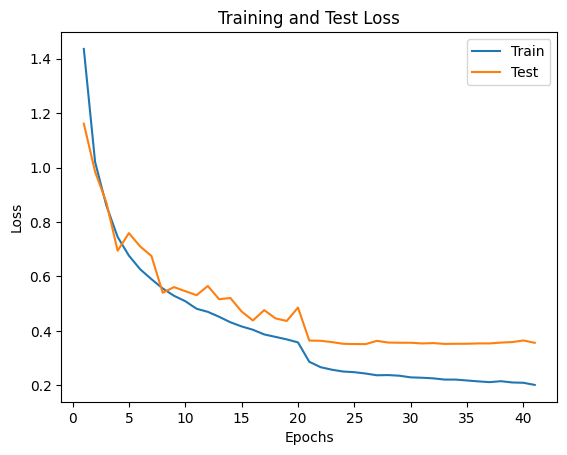

In [19]:
# =====================================================
# Loss Plot
# =====================================================

plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.plot(range(1, len(test_losses) + 1), test_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend(["Train", "Test"])
plt.show()

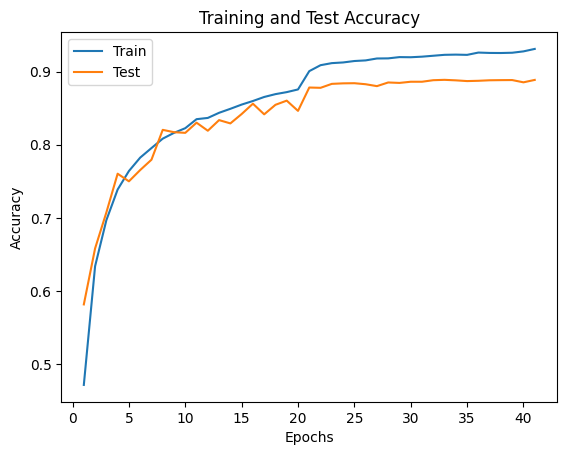

In [20]:
# =====================================================
# Accuracy Plot
# =====================================================
plt.figure()
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies)
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend(["Train", "Test"])
plt.show()

In [21]:
# =====================================================
# Show Specific CIFAR Test Images (One Row)
# =====================================================

classes = train_data.classes

def show_specific_images(indices):

    model.eval()
    num_images = len(indices)

    plt.figure(figsize=(3 * num_images, 3))

    for i, idx in enumerate(indices):

        image, label = test_data[idx]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Unnormalize image
        image_display = image * 0.5 + 0.5

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image_display.permute(1, 2, 0))

        correct = predicted.item() == label
        color = "green" if correct else "red"

        plt.title(
            f"P: {classes[predicted.item()]}\n"
            f"T: {classes[label]}",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

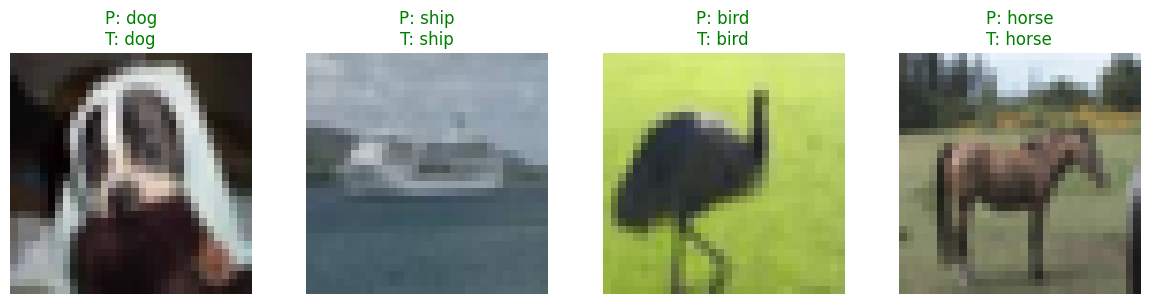

In [22]:
show_specific_images([4143, 3331, 123, 9999])

In [23]:
# =====================================================
# Show Random Test Predictions (One Row)
# =====================================================

classes = train_data.classes

def show_random_predictions(num_images=5):

    model.eval()
    indices = random.sample(range(len(test_data)), num_images)

    plt.figure(figsize=(3 * num_images, 3))  # wide figure

    for i, idx in enumerate(indices):

        image, label = test_data[idx]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        # Unnormalize image
        image_display = image * 0.5 + 0.5

        plt.subplot(1, num_images, i + 1)   # 1 row
        plt.imshow(image_display.permute(1, 2, 0))
        plt.title(
            f"P: {classes[predicted.item()]}\n"
            f"T: {classes[label]}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

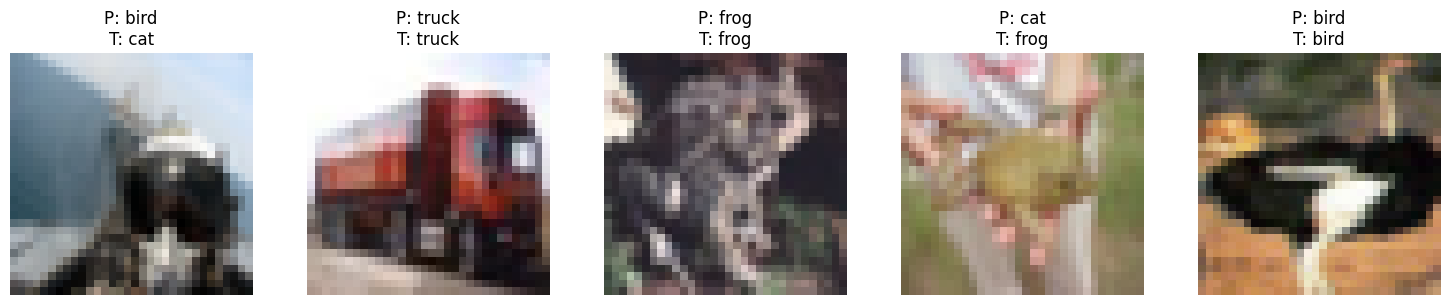

In [24]:
show_random_predictions(5)